Loaded 4000 loss values for learning rate 0.1
Loaded 4000 loss values for learning rate 0.01
Loaded 4000 loss values for learning rate 0.001
Loaded 4000 loss values for learning rate 0.0001


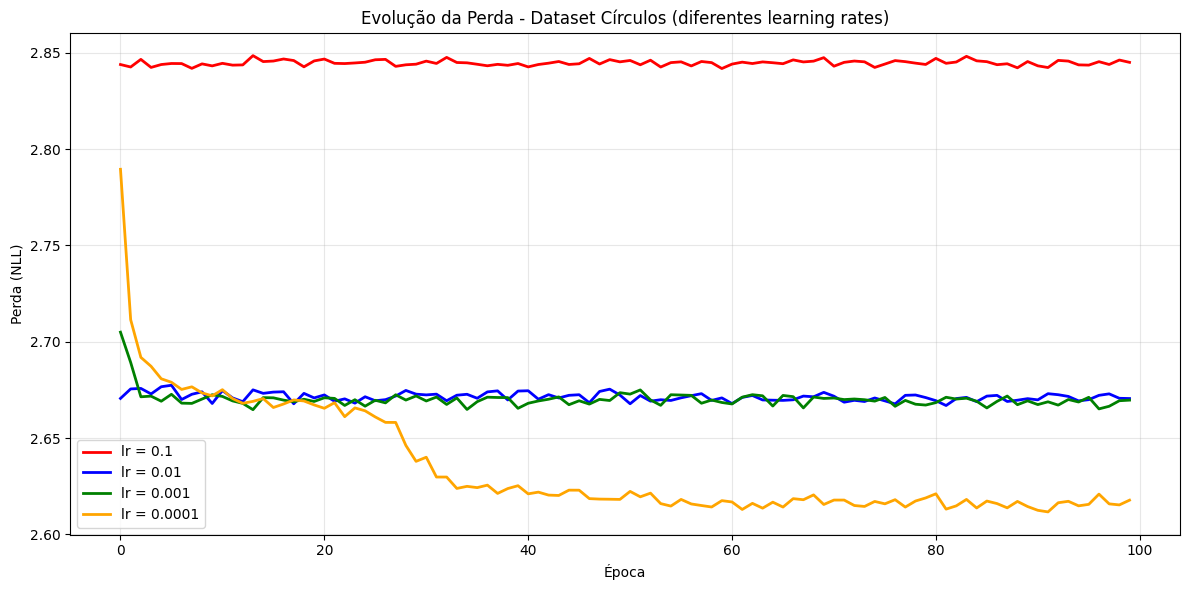

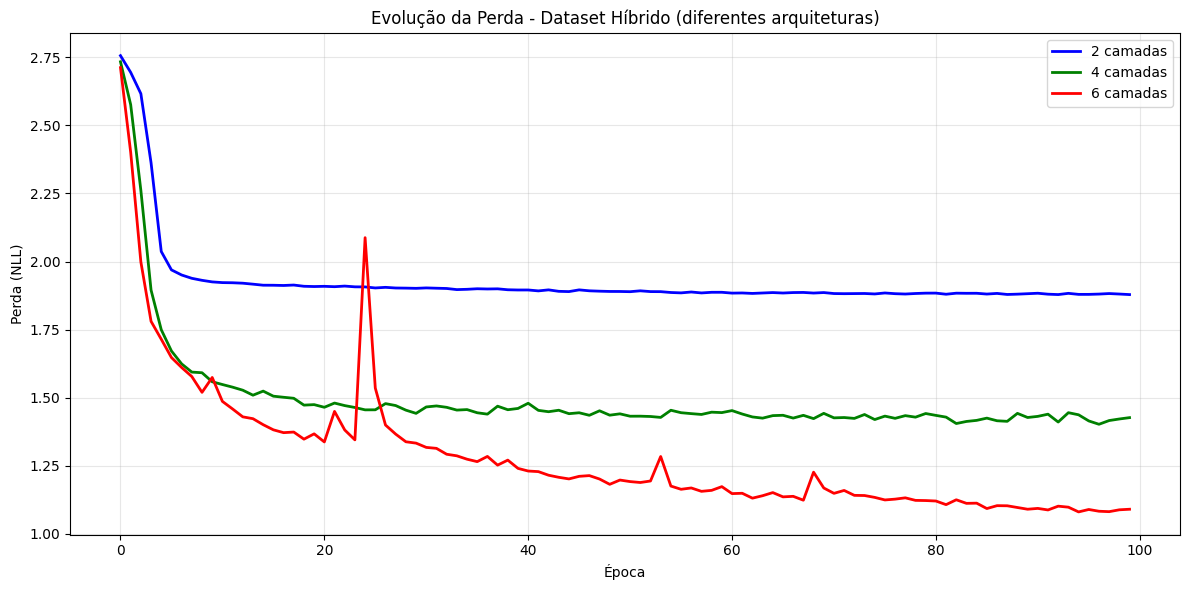

In [6]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Plot for circles dataset with different learning rates
def plot_circles_losses():
    plt.figure(figsize=(12, 6))
    
    learning_rates = [0.1, 0.01, 0.001, 0.0001]
    colors = ['red', 'blue', 'green', 'orange']
    
    for lr, color in zip(learning_rates, colors):
        try:
            with open(f"models/losses_circulos_{lr}.pkl", "rb") as f:
                losses = pickle.load(f)
                print(f"Loaded {len(losses)} loss values for learning rate {lr}")
            
            # Convert to epoch-wise averages (assuming batch_size and dataset structure)
            # Adjust batch calculation based on your actual setup
            batches_per_epoch = len(losses) // 100
            epoch_losses = []
            
            for epoch in range(100):
                start_idx = epoch * batches_per_epoch
                end_idx = (epoch + 1) * batches_per_epoch
                if end_idx <= len(losses):
                    epoch_loss = np.mean(losses[start_idx:end_idx])
                    epoch_losses.append(epoch_loss)
            
            plt.plot(range(len(epoch_losses)), epoch_losses, 
                    label=f'lr = {lr}', color=color, linewidth=2)
                    
        except FileNotFoundError:
            print(f"Arquivo losses_circulos_{lr}.pkl não encontrado")
    
    plt.xlabel('Época')
    plt.ylabel('Perda (NLL)')
    plt.title('Evolução da Perda - Dataset Círculos (diferentes learning rates)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('img/losses_circulos.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for hybrid dataset with different architectures
def plot_hybrid_losses():
    plt.figure(figsize=(12, 6))
    
    num_layers = [2, 4, 6]
    colors = ['blue', 'green', 'red']
    labels = ['2 camadas', '4 camadas', '6 camadas']
    
    for layers, color, label in zip(num_layers, colors, labels):
        try:
            # Assuming files are named with the number of layers
            with open(f"models/losses_hibrido_{layers}.pkl", "rb") as f:
                losses = pickle.load(f)
            
            # Convert to epoch-wise averages
            batches_per_epoch = len(losses) // 100  # assuming 100 epochs
            epoch_losses = []
            
            for epoch in range(100):
                start_idx = epoch * batches_per_epoch
                end_idx = (epoch + 1) * batches_per_epoch
                if end_idx <= len(losses):
                    epoch_loss = np.mean(losses[start_idx:end_idx])
                    epoch_losses.append(epoch_loss)
            
            plt.plot(range(len(epoch_losses)), epoch_losses, 
                    label=label, color=color, linewidth=2)
                    
        except FileNotFoundError:
            print(f"Arquivo losses_hibrido_{layers}.pkl não encontrado")
    
    plt.xlabel('Época')
    plt.ylabel('Perda (NLL)')
    plt.title('Evolução da Perda - Dataset Híbrido (diferentes arquiteturas)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('img/losses_hibrido.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create img directory if it doesn't exist
import os
os.makedirs('img', exist_ok=True)

# Generate both plots
plot_circles_losses()
plot_hybrid_losses()